# Binary routing classifier v0 (minimal)

Minimal baseline: predict `routing_label` **target** (1) vs **other** (0) from `article_text`.

**In scope:** stratified split → fixed TF-IDF + Logistic Regression → test metrics @0.5 → coefficients → spot checks.

**Out of scope here:** GridSearch / CV, abstain band (Layer B), threshold analytics.

Fuller pipeline: [`ml_binary_v1.ipynb`](ml_binary_v1.ipynb).


## 1. Setup


In [101]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [102]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    """Find data file whether the kernel cwd is project root or notebooks/."""
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )

DATA_PATH = resolve_data_path()
print("Loading:", DATA_PATH)


Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv


## 2. Load and label


In [104]:
df = pd.read_csv(DATA_PATH)
df["y"] = (df["routing_label"] == "target").astype(int)

print("shape:", df.shape)
print("nulls:", df[["article_text", "routing_label"]].isna().sum().to_dict())
print("\nlabel balance:")
print(df["routing_label"].value_counts())
print(df["y"].value_counts(normalize=True).rename("fraction"))


shape: (200, 13)
nulls: {'article_text': 0, 'routing_label': 0}

label balance:
routing_label
other     130
target     70
Name: count, dtype: int64
y
0    0.65
1    0.35
Name: fraction, dtype: float64


## 3. Stratified train / test split


In [106]:
X = df["article_text"]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("train pos rate:", y_train.mean().round(3))
print("test  pos rate:", y_test.mean().round(3))


train: 160  test: 40
train pos rate: 0.35
test  pos rate: 0.35


## 4. Fit fixed pipeline

No hyperparameter search — sensible defaults only.


In [108]:
model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
print("fitted on", len(X_train), "train rows")


fitted on 160 train rows


## 5. Test performance @ threshold 0.5

Always predict Target / Other. Default decision threshold only.

Also compare against label-only baselines to show the model is better than chance / class prior.


              precision    recall  f1-score   support

       other       0.75      0.69      0.72        26
      target       0.50      0.57      0.53        14

    accuracy                           0.65        40
   macro avg       0.62      0.63      0.63        40
weighted avg       0.66      0.65      0.65        40

F1     : 0.5333
ROC-AUC: 0.772
PR-AUC : 0.7201


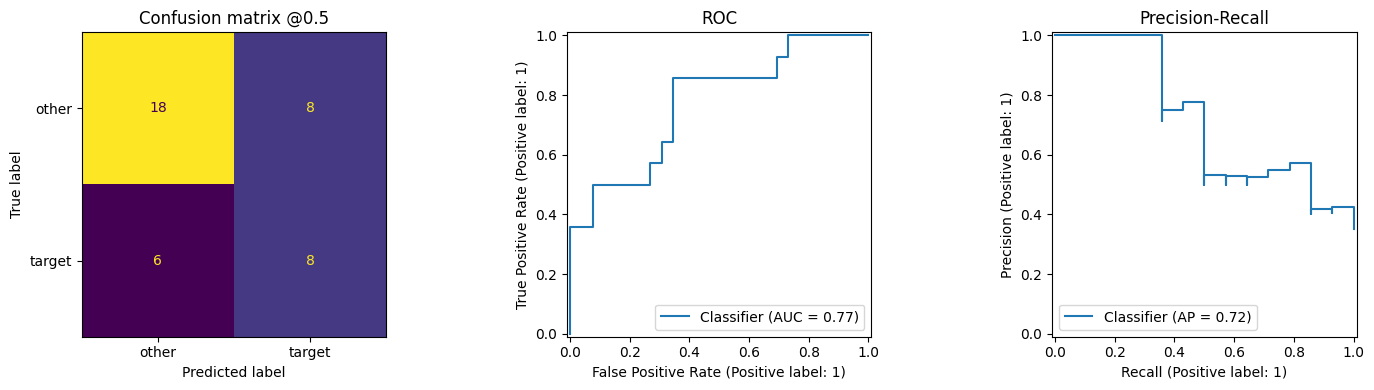

In [110]:
proba_test = model.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["other", "target"]))
print("F1     :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_test), 4))
print("PR-AUC :", round(average_precision_score(y_test, proba_test), 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["other", "target"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix @0.5")

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title("ROC")

PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2])
axes[2].set_title("Precision-Recall")

plt.tight_layout()
plt.show()


### Better than chance? — baseline comparison

Compare the fitted model to simple **label-only** baselines that **ignore `article_text`**:

| name | what it does |
|---|---|
| **TF-IDF + LR** | learns from article text |
| **Always majority class** | every row → most common **train** label (deterministic) |
| **Random w/ train rates** | each row randomly Target/Other with **train** class frequencies |
| **Coin flip 50/50** | each row fair coin; ignores train imbalance |

Majority ≠ random-with-rates even for 2 classes: one always picks the same label; the other still emits both classes at random.

If TF-IDF + LR beats these on the **same test set**, the model is using the text (not just label prevalence).


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
TF-IDF + LR,0.650,0.5000,0.5714,0.5333,0.7720,0.7201
Always majority class,0.650,0.0000,0.0000,0.0000,0.5000,0.3500
Random w/ train rates,0.525,0.2727,0.2143,0.2400,0.4533,0.3334
Coin flip 50/50,0.450,0.3000,0.4286,0.3529,0.5000,0.3500



F1 lift vs best label-only baseline: +0.1804  (model=0.5333, best_baseline=0.3529)


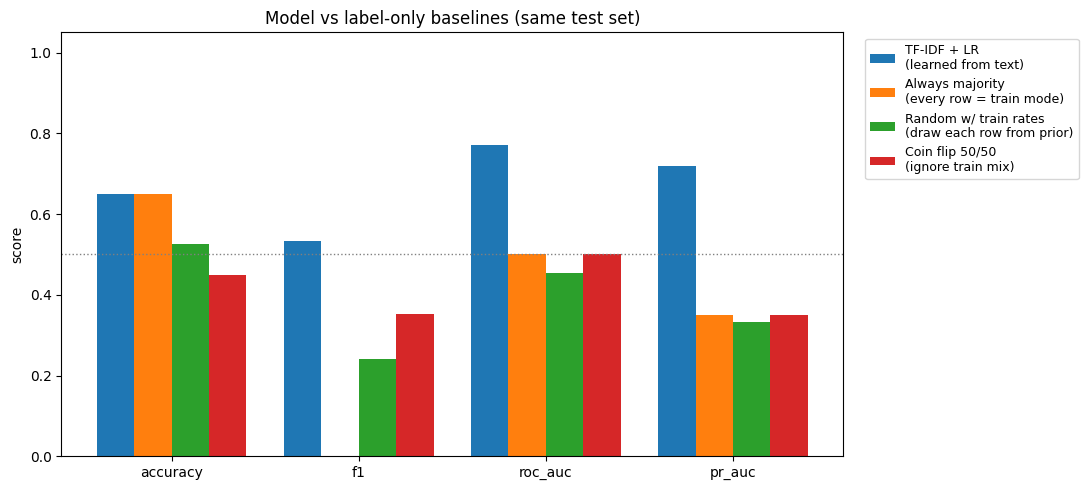

In [112]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

def eval_binary(name, y_true, y_hat, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

MODEL_NAME = "TF-IDF + LR"
baseline_rows = [
    eval_binary(MODEL_NAME, y_test, y_pred, proba_test),
]

# (display name, DummyClassifier strategy, short legend label for plot)
dummy_specs = [
    (
        "Always majority class",
        "most_frequent",
        "Always majority\n(every row = train mode)",
    ),
    (
        "Random w/ train rates",
        "stratified",
        "Random w/ train rates\n(draw each row from prior)",
    ),
    (
        "Coin flip 50/50",
        "uniform",
        "Coin flip 50/50\n(ignore train mix)",
    ),
]

legend_labels = {MODEL_NAME: "TF-IDF + LR\n(learned from text)"}
for name, strategy, legend in dummy_specs:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)  # X ignored; learns label prior only
    y_hat = dummy.predict(X_test)
    y_score = dummy.predict_proba(X_test)[:, 1]
    baseline_rows.append(eval_binary(name, y_test, y_hat, y_score))
    legend_labels[name] = legend

baseline_cmp = pd.DataFrame(baseline_rows).set_index("model")
display(baseline_cmp.round(4))

best_dummy_f1 = baseline_cmp.drop(index=MODEL_NAME)["f1"].max()
model_f1 = baseline_cmp.loc[MODEL_NAME, "f1"]
print(
    f"\nF1 lift vs best label-only baseline: {model_f1 - best_dummy_f1:+.4f}  "
    f"(model={model_f1:.4f}, best_baseline={best_dummy_f1:.4f})"
)

plot_metrics = ["accuracy", "f1", "roc_auc", "pr_auc"]
plot_df = baseline_cmp[plot_metrics]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_metrics))
width = 0.2
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=legend_labels[model_name])
ax.set_xticks(x + width * (len(plot_df) - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Model vs label-only baselines (same test set)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


## 6. Explainability — top coefficients

Tokens most associated with **target** (positive coef) vs **other** (negative coef).


,token_target,coef_target,token_other,coef_other
0,cloud,0.557747,rate,-0.413306
1,computing,0.549380,services,-0.412611
2,telecommunications,0.464959,financial services,-0.363637
3,cloud computing,0.449915,financial,-0.363637
4,workload,0.446301,retail,-0.327254
5,workload portability,0.446301,logistics,-0.279222
6,portability,0.446301,energy,-0.265976
7,installation,0.423501,rate monthly,-0.245423
8,installation speed,0.423501,transportation,-0.232158
9,service reliability,0.418279,retail and,-0.222555


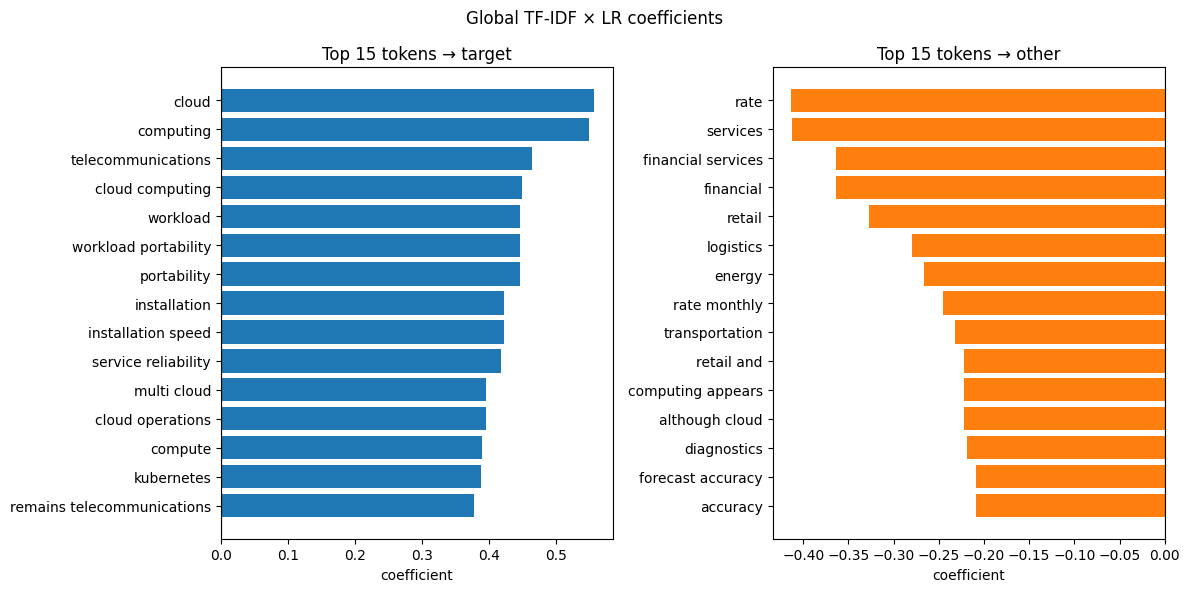

In [114]:
tfidf = model.named_steps["tfidf"]
clf = model.named_steps["clf"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_.ravel()

TOP_N = 15
pos_idx = np.argsort(coefs)[-TOP_N:][::-1]
neg_idx = np.argsort(coefs)[:TOP_N]

global_expl = pd.DataFrame({
    "token_target": feature_names[pos_idx],
    "coef_target": coefs[pos_idx],
    "token_other": feature_names[neg_idx],
    "coef_other": coefs[neg_idx],
})
display(global_expl)

# horizontal bar charts: largest |coef| at top of each panel
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

# target: plot ascending so largest positive is at top
t_tokens = feature_names[pos_idx][::-1]
t_coefs = coefs[pos_idx][::-1]
axes[0].barh(t_tokens, t_coefs, color="C0")
axes[0].set_title(f"Top {TOP_N} tokens → target")
axes[0].set_xlabel("coefficient")
axes[0].axvline(0, color="black", linewidth=0.8)

# other: most negative at top
o_tokens = feature_names[neg_idx][::-1]
o_coefs = coefs[neg_idx][::-1]
axes[1].barh(o_tokens, o_coefs, color="C1")
axes[1].set_title(f"Top {TOP_N} tokens → other")
axes[1].set_xlabel("coefficient")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.suptitle("Global TF-IDF × LR coefficients")
plt.tight_layout()
plt.show()


## 7. Spot checks — correct and incorrect predictions

Inspect a few test examples from each confusion-matrix cell (when available): title, true label, predicted label, `P(target)`, text snippet.


In [116]:
def show_spot_checks(n_per_bucket: int = 2, snippet_chars: int = 240):
    test_df = pd.DataFrame({
        "article_id": df.loc[X_test.index, "article_id"].values,
        "title": df.loc[X_test.index, "title"].values,
        "article_text": X_test.values,
        "y_true": y_test.values,
        "y_pred": y_pred,
        "p_target": proba_test,
    })
    test_df["true_label"] = np.where(test_df["y_true"] == 1, "target", "other")
    test_df["pred_label"] = np.where(test_df["y_pred"] == 1, "target", "other")

    buckets = {
        "TP (correct target)": (test_df["y_true"] == 1) & (test_df["y_pred"] == 1),
        "TN (correct other)": (test_df["y_true"] == 0) & (test_df["y_pred"] == 0),
        "FP (false target)": (test_df["y_true"] == 0) & (test_df["y_pred"] == 1),
        "FN (false other)": (test_df["y_true"] == 1) & (test_df["y_pred"] == 0),
    }

    for name, mask in buckets.items():
        subset = test_df.loc[mask].copy()
        print("=" * 72)
        print(f"{name}: {len(subset)} in test")
        if subset.empty:
            print("(none)")
            continue
        # prefer high-confidence mistakes / correct preds
        subset = subset.assign(conf=np.abs(subset["p_target"] - 0.5)).sort_values(
            "conf", ascending=False
        )
        for _, row in subset.head(n_per_bucket).iterrows():
            snippet = row["article_text"][:snippet_chars].replace("\n", " ")
            print("-" * 72)
            print(f"article_id={row['article_id']} | true={row['true_label']} | "
                  f"pred={row['pred_label']} | P(target)={row['p_target']:.3f}")
            print("title:", row["title"][:120])
            print("text:", snippet, "...")
        print()

show_spot_checks()


TP (correct target): 8 in test
------------------------------------------------------------------------
article_id=V4-0026 | true=target | pred=target | P(target)=0.639
title: A Practical Guide to Private Wireless
text: At a practical level, private wireless changes how organizations provision capacity, manage reliability, and measure capital intensity.  Several organizations have adopted a pilot-first approach. They are limiting the initial scope, documen ...
------------------------------------------------------------------------
article_id=V4-0045 | true=target | pred=target | P(target)=0.633
title: Vertex Cloud Systems Announces Multi-Year Serverless Computing Investment
text: Vertex Cloud Systems introduced a new program focused on serverless computing, positioning the effort as part of a broader operational modernization plan.  Workforce constraints are another concern. Companies need technical specialists as w ...

TN (correct other): 18 in test
---------------------------------

## Save trained model

Saves the fitted TF-IDF + LR pipeline.

Artifact → `models/ml_binary_v0.joblib` (next to `data/`).


In [118]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_binary_v0.joblib"

joblib.dump(model, MODEL_PATH)
print("saved:", MODEL_PATH.resolve())
print("reload example: loaded = joblib.load(MODEL_PATH)")


saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_binary_v0.joblib
reload example: loaded = joblib.load(MODEL_PATH)


## Next

- Hyperparam tuning, CV diagnostics, Layer B abstain band, richer explainability → [`ml_binary_v1.ipynb`](ml_binary_v1.ipynb)
- Broader roadmap (embeddings, data, features, etc.) → Notes section in that notebook
